<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
Supplementary code for the <a href="https://mng.bz/lZ5B">Build a Reasoning Model (From Scratch)</a> book by <a href="https://sebastianraschka.com">Sebastian Raschka</a><br>
<br>Code repository: <a href="https://github.com/rasbt/reasoning-from-scratch">https://github.com/rasbt/reasoning-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="https://mng.bz/lZ5B"><img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# 第4章：通过推理时扩展提升推理能力

本 Notebook 使用到的依赖包：

In [65]:
%pip install -r https://raw.githubusercontent.com/rasbt/reasoning-from-scratch/refs/heads/main/requirements.txt  # 安装项目依赖
from importlib.metadata import version  # 获取已安装库的版本信息

used_libraries = [                       # 需要查询版本的库列表
    "matplotlib",                        # 绘图库
    "reasoning_from_scratch",            # 本项目主库
    "torch",                             # 深度学习库
    "tokenizers"                         # 被项目依赖的分词器库
]

for lib in used_libraries:               # 逐个库打印版本
    print(f"{lib} version: {version(lib)}")


matplotlib version: 3.10.7
reasoning_from_scratch version: 0.1.10
torch version: 2.9.0+cu126
tokenizers version: 0.22.1


<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F01_raschka.webp" width=600>

&nbsp;
## 4.1 推理时扩展简介

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F02_raschka.webp" width=600>

- 上图灵感来自 OpenAI o1 博文 https://openai.com/index/learning-to-reason-with-llms/

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F03_raschka.webp" width=600>

- 这三种方法都能把基础模型在 MATH-500（上一章的基准）上的准确率提升到两倍以上。
- 第 1、2 种方法在本章讲解，第 3 种方法放到下一章。

&nbsp;
## 4.2 加载预训练模型

- 模型加载代码与第 2、3 章类似。

In [66]:
import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()                     # 自动检测可用设备（CUDA/MPS/CPU）

# 首次运行本章时强制使用 CPU，避免兼容性问题
device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(  # 加载 Qwen3 模型与分词器
    which_model="base",                       # 选择基础版模型
    device=device,                            # 放到指定设备
    use_compile=False                         # 不使用 torch.compile
)


Using NVIDIA CUDA GPU
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


- 先用上一章接触过的 MATH-500 数据集题目来试试模型：

In [67]:
from reasoning_from_scratch.ch03 import render_prompt  # 导入提示模板构造函数

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)  # 原始题目字符串
prompt = render_prompt(raw_prompt)  # 用模板包装成完整提示词

print(prompt)  # 打印生成的提示


You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


- 下方这个函数基于上一章的 `generate_text_stream_concat`，不过我们稍作调整，以便后续可以传入其他 `generate_*` 函数。

In [68]:
from reasoning_from_scratch.ch02_ex import generate_text_basic_stream_cache  # 默认的流式生成函数（已存在）

def generate_text_stream_concat_flex(                   # 定义可插拔生成器的包装函数
    model, tokenizer, prompt, device, max_new_tokens,
    verbose=False,
    generate_func=None,  # 新增：允许传入自定义生成函数
    **generate_kwargs    # 新增：向生成函数透传额外参数
):

    if generate_func is None:                           # 新增：未提供自定义生成器则使用默认
        generate_func = generate_text_basic_stream_cache
        
    input_ids = torch.tensor(                           # 将提示词编码为张量
        tokenizer.encode(prompt), device=device
    ).unsqueeze(0)                                      # 添加 batch 维度

    generated_ids = []                                  # 存放生成的 token id
    for token in generate_func(                         # 新增：调用可替换的生成函数
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,                              # 新增：透传附加参数（如温度、top_k 等）
    ):
        next_token_id = token.squeeze(0)                # 去掉 batch 维度
        generated_ids.append(next_token_id.item())      # 收集生成的单个 token id

        if verbose:                                     # 如果需要实时输出
            print(
                tokenizer.decode(next_token_id.tolist()),
                end="",
                flush=True
            )
    return tokenizer.decode(generated_ids)              # 解码全部生成结果为字符串并返回


In [69]:
response = generate_text_stream_concat_flex(                 # 调用可插拔生成包装函数
    model, tokenizer, prompt, device,                       # 传入模型、分词器、提示词与设备
    max_new_tokens=2048, verbose=True,                      # 设置最大生成长度与实时输出
    generate_func=generate_text_basic_stream_cache          # NEW：显式指定使用基础流式生成器
)


 \boxed{10}

- 顺带一提，正确答案是 83。

&nbsp;
## 4.3 使用链式思维提示来生成更好的回答

- 提升模型表现的经典方法之一，就是改写提示语，鼓励它逐步思考或逐步解释。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F04_raschka.webp" width=600>" 

In [70]:
prompt_cot = prompt + " \n\nExplain step by step."            # 在原提示后追加“逐步解释”指令
                                                               # （保持空行让模型清晰分段）

response_cot = generate_text_stream_concat_flex(               # 调用可插拔生成函数
    model, tokenizer, prompt_cot, device,                      # 传入模型、分词器、扩展提示和设备
    max_new_tokens=2048, verbose=True,                         # 设定最大生成长度并开启流式打印
)                                                              # 使用默认生成器（未显式覆盖 generate_func）


 To solve the problem, we need to find the value of \( x \) such that half the value of \( 3x - 9 \) is equal to \( x + 37 \).

### Step 1: Set up the equation
According to the problem, half the value of \( 3x - 9 \) is equal to \( x + 37 \). This can be written as:
\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 2: Eliminate the fraction
To eliminate the fraction, multiply both sides of the equation by 2:
\[
2 \cdot \frac{1}{2}(3x - 9) = 2(x + 37)
\]
Simplifying both sides:
\[
3x - 9 = 2x + 74
\]

### Step 3: Solve for \( x \)
Subtract \( 2x \) from both sides to isolate \( x \):
\[
3x - 2x - 9 = 74
\]
Simplify:
\[
x - 9 = 74
\]
Add 9 to both sides to solve for \( x \):
\[
x = 74 + 9
\]
\[
x = 83
\]

### Final Answer:
\[
\boxed{83}
\]

&nbsp;
## 4.4 通过温度缩放控制输出多样性

- 到目前为止我们使用的都是确定性解码，本节将引入随机解码。
- 先从温度缩放开始，随后在第 4.5 节加入 top-p，以更好地平衡随机性与连贯性。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F05_raschka.webp" width=600>

&nbsp;
### 4.4.1 理解选择下一个 token 的过程

In [71]:
ex_prompt = "The capital of Germany is"                 # 构造一个简单提示，用于测试单词生成

response = generate_text_stream_concat_flex(            # 调用可插拔生成函数
    model, tokenizer, ex_prompt, device,                # 传入模型、分词器、提示词与设备
    max_new_tokens=1, verbose=True                      # 最多生成 1 个 token，开启流式打印
)                                                       # 使用默认生成器（未覆盖 generate_func）


 Berlin

- 内部具体发生了什么：

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F06_raschka.webp" width=600>

In [72]:
# 1) 将输入文本编码为 token ID
input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device  # 分词器编码后放到指定设备
).unsqueeze(0)                                 # 添加 batch 维度，形状变为 (1, seq_len)

print(input_token_ids)                         # 打印编码后的张量


tensor([[ 785, 6722,  315, 9856,  374]])


In [73]:
# 2) 计算下一个 token 的 logits 分数
with torch.inference_mode():                         # 关闭梯度，推理模式
    next_token_logits = model(input_token_ids)[:, -1] # 前向计算后取序列末位的 logits
print(next_token_logits.shape)                        # 打印形状，应为 [1, vocab_size]


torch.Size([1, 151936])


In [74]:
# 3) 找到得分最高的词表索引
max_token_id = torch.argmax(next_token_logits)                 # 取 logits 最大值对应的 token ID
print(f"Token ID: {max_token_id}")                             # 打印该 token 的 ID
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")  # 解码并打印对应的 token 文本


Token ID: 19846
Decoded token: ' Berlin'


- 这个 LLM 的词表有 151,936 个 token（索引 0151,935）；为了方便展示，我们只关注索引 19,800 到 19,900 之间的 100 个 token。

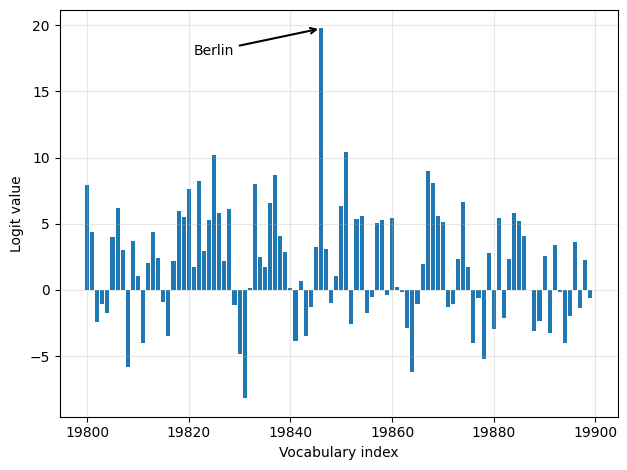

In [75]:
import matplotlib.pyplot as plt  # 绘图库

def plot_scores_bar(
    next_token_logits, start=19_800, end=19_900,
    arrow=True, ylabel="Logit value"
):
    x = torch.arange(start, end)                          # 选择词表片段的索引范围
    logits_section = next_token_logits[0, start:end].float().cpu()  # 裁剪并转为 CPU 上的浮点张量
    plt.bar(x, logits_section)                            # 绘制柱状图
    plt.xlabel("Vocabulary index")                        # 设置 x 轴标签
    plt.ylabel(ylabel)                                    # 设置 y 轴标签

    if arrow:                                             # 若需要标注最大值
        max_idx = torch.argmax(logits_section)            # 找到片段内最大 logit 的位置
        plt.annotate(                                     # 添加注释和箭头
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
            fontsize=10,
        )

    plt.grid(alpha=0.3)                                   # 添加网格，透明度 0.3
    plt.tight_layout()                                    # 紧凑布局防止遮挡
    plt.show()                                            # 显示图像

plot_scores_bar(next_token_logits)                        # 绘制指定 logits 片段的柱状图


&nbsp;
###  通过温度参数重标定 token 得分（logits）

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F08_raschka.webp" width=600>

In [76]:
def scale_logits_by_temperature(logits, temperature):  # 温度缩放函数：按给定温度调整 logits
    if temperature <= 0:                               # 温度需为正，否则抛异常
        raise ValueError("Temperature must be positive")
    return logits / temperature                        # 通过除以温度缩放 logits（温度高→分布更平滑）


- 从严谨的可视化角度来说，柱状图更合适；不过折线图能更直观地对比差异。

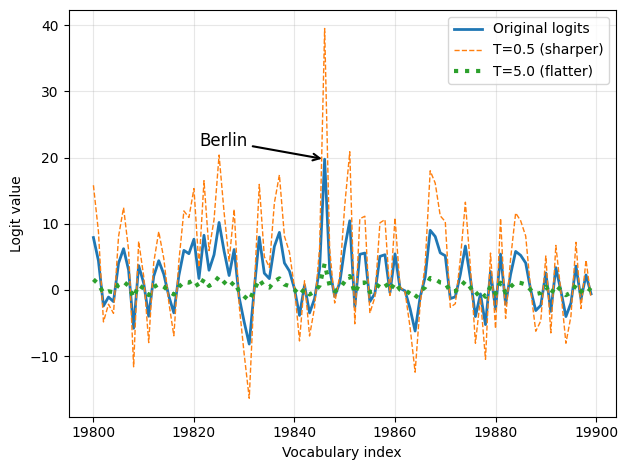

In [77]:
def plot_logits_with_temperature(                          # 绘制温度缩放前后 logits 曲线
    next_token_logits, start=19_800, end=19_900,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)                           # 选取词表区间的索引
    logits_orig = next_token_logits[0, start:end].float().cpu()  # 切片并转为 CPU 浮点

    # 应用温度缩放，得到不同温度下的 logits
    logits_scaled = [
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]
    # 绘制原始 logits 曲线
    plt.plot(x, logits_orig, label="Original logits", lw=2)
    # 绘制较低温度（更尖锐）的曲线
    plt.plot(
        x, logits_scaled[0],
        label=f"T={temps[0]} (sharper)", ls="--", lw=1
    )
    # 绘制较高温度（更平滑）的曲线
    plt.plot(
        x, logits_scaled[1],
        label=f"T={temps[1]} (flatter)", ls=":", lw=3
    )

    max_idx = torch.argmax(logits_orig)                    # 找到原始 logits 最大值的索引
    plt.annotate(                                          # 对最大值添加文字与箭头
        "Berlin",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )

    plt.xlabel("Vocabulary index")                         # 设置 x 轴标签
    plt.ylabel("Logit value")                              # 设置 y 轴标签
    plt.legend()                                           # 显示图例
    plt.grid(alpha=0.3)                                    # 添加网格
    plt.tight_layout()                                     # 紧凑布局
    plt.show()                                             # 显示图像

plot_logits_with_temperature(                              # 调用函数进行绘制
    next_token_logits,
    temps=(0.5, 5.0)
)


&nbsp;
### 4.4.3 从概率分布中采样下一个 token

- 将 logits 得分转化为概率得分（总和为 1）。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F10_raschka.webp" width=600>

In [78]:
# Step 3.2: Rescale next-token scores
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)  # 按温度 5.0 对 logits 进行缩放

# Step 3.3 Convert rescaled logits into probability scores
next_token_probas = torch.softmax(                                    # 对缩放后的 logits 做 softmax 得到概率分布
    rescaled_logits, dim=-1
)

print("Probability sum:", torch.sum(next_token_probas))                # 验证概率分布求和是否为 1


Probability sum: tensor(1., dtype=torch.bfloat16)


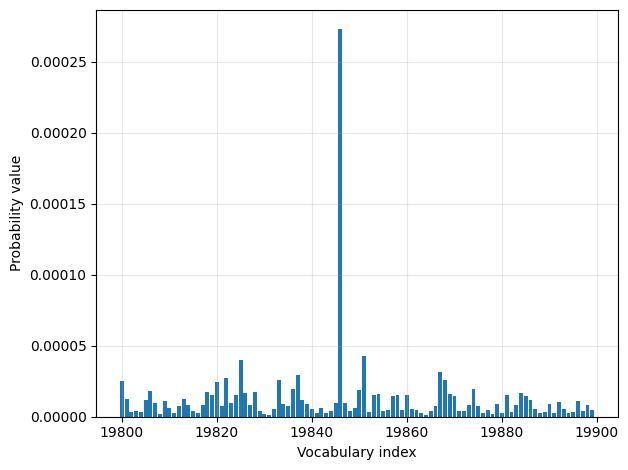

In [79]:
plot_scores_bar(                                        # 调用绘图函数，展示概率分布的柱状图
    next_token_probas, arrow=False, ylabel="Probability value"  # 传入概率张量；不绘箭头；Y 轴标注为概率值
)


In [80]:
print("Token ID 19,846 probability:", next_token_probas[:, 19846])  # 输出词表 ID 19,846 的概率值


Token ID 19,846 probability: tensor([0.0003], dtype=torch.bfloat16)


In [81]:
print("Highest probability:", max(next_token_probas.squeeze(0)))  # 取概率分布中的最大值并打印


Highest probability: tensor(0.0003, dtype=torch.bfloat16)


In [82]:
# Step 3.4: 按概率分布进行采样
torch.manual_seed(123)                                          # 设定随机种子以保证采样可复现
print(
    "Sampled token:",
    torch.multinomial(next_token_probas.cpu(), num_samples=1)   # 从概率分布中抽取 1 个 token ID
)


Sampled token: tensor([[65094]])


In [83]:
print(tokenizer.decode([65094]))  # 解码并打印词表 ID 65094 对应的 token 文本


 mistress


In [84]:
def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):  # 按给定概率分布重复采样并统计频次
    samples = torch.multinomial(                                          # 根据概率分布抽样 num_samples 次
        probas.cpu(), num_samples=num_samples, replacement=True
    )
    counts = torch.bincount(samples.squeeze(0), minlength=1)              # 统计每个词表索引被选中的次数
    for i, c in enumerate(counts):                                        # 遍历所有索引的计数
        if c > threshold:                                                 # 只打印超过阈值的索引
            if tokenizer is None:                                         # 如未传入分词器，直接打印索引
                print(f"Vocab index {i}: {c.item()}x")
            else:                                                         # 传入分词器则解码索引对应 token
                print(f"'{tokenizer.decode([i])}': {c.item()}x")


In [85]:
torch.manual_seed(123)                     # 固定随机种子，确保采样结果可复现
count_samples(next_token_probas, tokenizer=tokenizer)  # 按概率分布重复采样并统计 token 频次


'}': 2x
' your': 2x
' Oh': 2x
' dos': 2x
' grocery': 2x
' Going': 2x
' Troy': 2x
' overdose': 2x
'וא': 2x
' thêm': 2x


In [86]:
torch.manual_seed(123)  # 固定随机种子，保证采样结果可复现
probas_lowT = torch.softmax(  # 计算低温度下的概率分布（新增）
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1  # 将 logits 以温度 0.35 缩放后做 softmax（新增）
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)  # 按低温度概率反复采样并统计频次（新增）


'
': 2x
' __': 130x
' Berlin': 453x
' ____': 173x
' ______': 213x
' Hamburg': 5x
' _____': 19x


In [87]:
print(probas_lowT[0, 19_846])  # 打印低温度分布下词表 ID 19,846 的概率


tensor(0.4355, dtype=torch.bfloat16)


- 之所以出现 `"______"`，很可能是模型在训练数据里见过类似格式，于是尝试为用户生成一道填空题。

&nbsp;
### 4.4.4 在文本生成函数中加入温度缩放参数

In [88]:
# Exercise 2.2 Appendix B
from reasoning_from_scratch.qwen3 import KVCache            # 导入 KV 缓存类，用于存储键值对以加速解码
                                                             # （新增：需要 KVCache 支持）

@torch.inference_mode()                                     # 推理模式，禁用梯度计算
def generate_text_temp_stream_cache(                        # 定义带温度采样和缓存的流式生成函数
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.                                          # 默认温度 0（等价于贪心）
):
    model.eval()                                            # 设为评估模式
    cache = KVCache(n_layers=model.cfg["n_layers"])         # 新增：根据模型层数创建 KV 缓存
    model.reset_kv_cache()                                  # 新增：重置模型内部缓存状态

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]              # 前向计算并取当前步 logits
    for _ in range(max_new_tokens):                         # 迭代生成最多 max_new_tokens 个新 token

        ########################################
        # NEW:
        orig_device = token_ids.device                      # 新增：记录原始设备，便于采样后移回

        if temperature is None or temperature == 1.0:       # 新增：温度为 None 或 1.0 时用贪心
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)  # 新增：按温度缩放 logits

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)          # 新增：softmax 得到概率分布

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)  # 新增：按概率采样
            next_token = next_token.to(orig_device)         # 新增：将采样结果移回原设备
            
        #########################################
        if (eos_token_id is not None                        # 若设置了 eos 且生成到 eos，则停止
                and next_token.item() == eos_token_id):
            break

        yield next_token                                    # 产出当前生成的 token
        out = model(next_token, cache=cache)[:, -1]         # 继续前向计算下一步 logits，复用缓存


In [89]:
torch.manual_seed(123)                                        # 固定随机种子，确保采样可复现
response = generate_text_stream_concat_flex(                  # 调用可插拔的流式生成包装
    model, tokenizer, prompt, device,                         # 传入模型、分词器、提示词与设备
    max_new_tokens=2048, verbose=True,                        # 最多生成 2048 个 token，开启实时输出
    generate_func=generate_text_temp_stream_cache,            # 使用带温度采样与 KV 缓存的生成器
    temperature=1.1                                           # 设置温度为 1.1，增加多样性
)


 We begin with the equation \(\frac{1}{2}(3x - 9) = x + 37\).
First, distribute the \(\frac{1}{2}\) on the left-side of the equation to get \(3x - 9 = 2(x + 37)\).
Then simplify the right side of the equation by using the distributive property and combining like terms: \(3x - 9 = 2x + 74\).
Next, subtract \(2x\) from both sides of the equation to get \(x - 9 = 2x + 74\).
Next, subtract \(x\) from both sides of the equation to reduce the number of \(x\) terms on the right side to exactly 1: \(-9 = x + 74\).
Finally, subtract 74 from both sides of the equation to get \(x = -83\).
The value of \(x\) is \(\boxed{-83}\).

&nbsp;
## 4.5 通过 top-p 采样平衡多样性与连贯性

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F12_raschka.webp" width=600>

&nbsp;
### 4.5.1 选择 top-p 子集 token

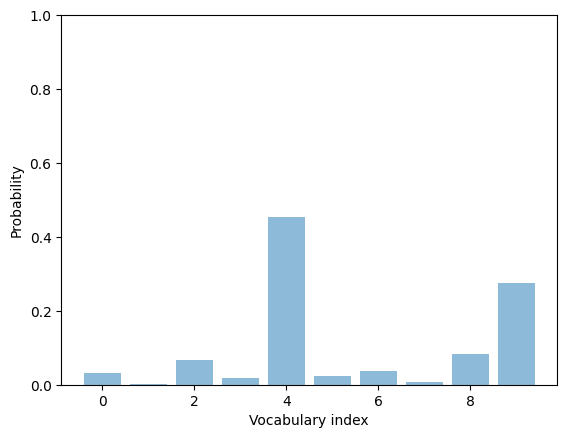

In [90]:
# Step 3.1: 获取 logits（这里用 10 个 token 的示例 logits）
toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)

# Step 3.2: 按温度缩放 logits（温度 1.0 等价于不变）
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)

# Step 3.3: 将缩放后的 logits 转为概率分布
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)

plt.bar(                                  # 绘制柱状图展示概率
    torch.arange(len(toy_logits_scaled)), # x 轴为词表索引
    toy_probas,                           # y 轴为对应概率
    alpha=0.5
)

plt.ylim([0, 1])                          # 限制 y 轴范围到 [0,1]
plt.xlabel("Vocabulary index")            # x 轴标签
plt.ylabel("Probability")                 # y 轴标签
# plt.savefig("12.pdf")                   # 如需保存图像可取消注释
plt.show()                                # 显示图像


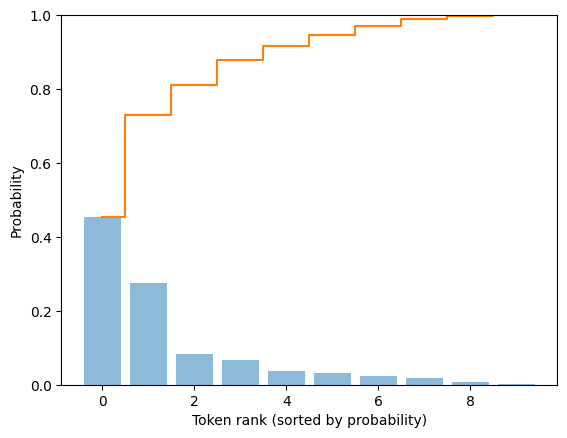

In [91]:
# Step 4.1: 按概率从大到小排序
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)

# Step 4.2: 计算累积概率
cumsum = torch.cumsum(sorted_probas, dim=-1)

plt.bar(                                          # 绘制排序后的概率柱状图
    torch.arange(len(sorted_probas)), sorted_probas, 
    alpha=0.5
)
plt.step(                                         # 绘制累积概率阶梯线
    torch.arange(len(cumsum)), cumsum, 
    where="mid", color="C1", label="Cumulative sum"
)

plt.ylim([0, 1])                                  # y 轴限制在 [0,1]
plt.xlabel("Token rank (sorted by probability)")  # x 轴标签：按概率排序的 token 名次
plt.ylabel("Probability")                         # y 轴标签：概率
plt.show()                                        # 显示图像


In [92]:
# Step 4.3.1: 应用 top-p 阈值（例如累积概率超过 0.8 后的 token 舍弃）
top_p = 0.8                              # 设定 top-p 阈值
keep_mask = cumsum <= top_p              # 布尔掩码：累积概率未超过阈值的 token 标记为 True
n_kept = torch.sum(keep_mask).item()     # 统计保留的 token 数量


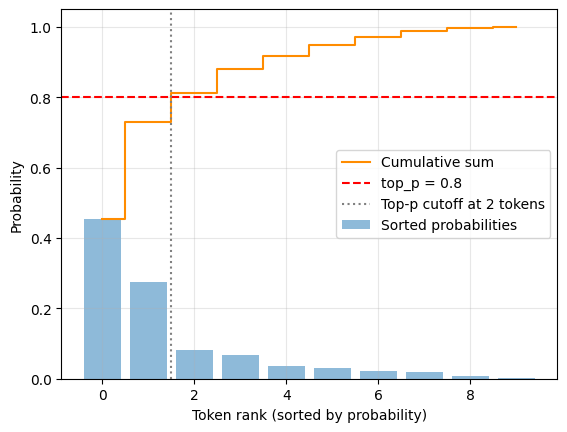

In [93]:
plt.bar(                                                    # 绘制排序后的概率柱状图
    torch.arange(len(sorted_probas)), sorted_probas, 
    alpha=0.5, label="Sorted probabilities"
)
plt.step(                                                   # 绘制累积概率阶梯线
    torch.arange(len(cumsum)), cumsum, where="mid",
    color="darkorange", label="Cumulative sum"
)

# 高亮截断阈值
plt.axhline(                                               # 水平线表示 top-p 阈值
    top_p, color="red", linestyle="--",
    label=f"top_p = {top_p}"
)
plt.axvline(                                               # 垂直线表示保留的 token 个数位置
    n_kept - 0.5, color="gray", linestyle=":",
    label=f"Top-p cutoff at {n_kept} tokens"
)

plt.xlabel("Token rank (sorted by probability)")          # x 轴标签
plt.ylabel("Probability")                                 # y 轴标签
plt.legend()                                              # 显示图例
plt.grid(alpha=0.3)                                       # 添加网格
plt.ylim(0, 1.05)                                         # 调整 y 轴范围
# plt.savefig("14.pdf")                                   # 如需保存图像可取消注释
plt.show()                                                # 显示图像


In [94]:
# Step 4.3.2: 在排序后的序列中，将超出 top-p 截断的概率置零
kept_sorted = torch.where(
    keep_mask, sorted_probas,
    torch.zeros_like(sorted_probas)
)

# Step 4.3.3: 按原始词表顺序还原，未保留的概率为 0
filtered = torch.zeros_like(toy_probas).scatter(0, sorted_idx, kept_sorted)

print(filtered)  # 打印按原顺序排列、已截断后的概率分布


tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.4538, 0.0000, 0.0000, 0.0000, 0.0000,
        0.2752])


In [95]:
# Step 4.4: 将截断后的概率重新归一化，使总和为 1
denom = torch.sum(filtered).clamp_min(1e-12)  # 计算和并设下界，防止除零
renormalized = filtered / denom               # 用总和归一化每个概率
print(renormalized)                           # 打印归一化后的概率分布


tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.6225, 0.0000, 0.0000, 0.0000, 0.0000,
        0.3775])


&nbsp;
### 4.5.2 在文本生成函数中加入 top-p 过滤器

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F16_raschka.webp" width=600>

In [96]:
def top_p_filter(probas, top_p):                     # 对概率分布执行 top-p 过滤
    if top_p is None or top_p >= 1.0:                # 若不设 top-p 或 top-p>=1，直接返回原分布
        return probas

    # Step 4.1: 按概率降序排序
    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)

    # Step 4.2: 计算累积和
    cumprobas = torch.cumsum(sorted_probas, dim=1)

    # Step 4.3.1: 保留累积概率未超过 top-p 的 token
    keep = cumprobas <= top_p
    keep[:, 0] = True                                # top_p<=0 时至少保留最高概率 token 作为兜底

    # Step 4.3.2: 截断后其余概率置零
    kept_sorted = torch.where(
        keep, sorted_probas,
        torch.zeros_like(sorted_probas)
    )
    # Step 4.3.3: 将截断结果映射回原始索引顺序
    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)

    # Step 4.4: 归一化使概率和为 1（可选但常用）
    denom = torch.sum(filtered, dim=1).clamp_min(1e-12)
    return filtered / denom


In [97]:
with torch.inference_mode():                     # 关闭梯度与优化器状态，进入推理模式
    next_token_logits = model(input_token_ids)[:, -1]  # 前向计算，并取序列最后一个位置的 logits
print(next_token_logits.shape)                   # 打印 logits 张量的形状


torch.Size([1, 151936])


In [98]:
torch.manual_seed(123)  # 固定随机种子，保证采样结果可复现
probas_lowT = torch.softmax(  # 先按温度缩放 logits，再做 softmax 得到低温度下的概率分布
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)  # 基于低温度概率分布反复采样并统计频次（仅打印次数大于阈值的 token）


'
': 2x
' __': 130x
' Berlin': 453x
' ____': 173x
' ______': 213x
' Hamburg': 5x
' _____': 19x


In [99]:
torch.manual_seed(123)  # 固定随机种子，保证采样可复现
probas_lowT = torch.softmax(  # 先温度缩放 logits 再做 softmax 得到低温度概率分布
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)  # 应用 top-p=0.8 过滤并重新归一化（新增）

count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)  # 按过滤后的分布采样并统计出现频次


' Berlin': 683x
' ______': 317x


In [100]:
@torch.inference_mode()                                         # 推理模式，关闭梯度
def generate_text_top_p_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.,
    top_p=None                                                  # 新增：top-p 过滤阈值
):
    model.eval()                                                # 评估模式
    cache = KVCache(n_layers=model.cfg["n_layers"])             # 新增：创建 KV 缓存
    model.reset_kv_cache()                                      # 新增：重置模型内部缓存

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]                  # 前向计算并取序列末尾 logits
    for _ in range(max_new_tokens):                             # 最多生成 max_new_tokens 个

        orig_device = token_ids.device                          # 记录原始设备（新增）

        if temperature is None or temperature == 1.0:           # 温度为空或 1.0 则贪心
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)  # 按温度缩放 logits（新增）

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)                   # softmax 得到概率（新增）

            # (New) Step 4: Apply top-p filter to probabilities
            probas = top_p_filter(probas, top_p)                     # 新增：应用 top-p 过滤

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)  # 概率采样（新增）
            next_token = next_token.to(orig_device)                  # 移回原设备（新增）

        if (eos_token_id is not None                                 # 遇到 EOS 则停止
                and next_token.item() == eos_token_id):
            break

        yield next_token                                             # 产出当前 token
        out = model(next_token, cache=cache)[:, -1]                  # 用缓存继续前向，获得新 logits


In [101]:
torch.manual_seed(123)                                   # 固定随机种子，保证采样可复现
response = generate_text_stream_concat_flex(             # 调用可插拔的流式生成包装
    model, tokenizer, prompt, device,                    # 传入模型、分词器、提示词与设备
    max_new_tokens=2048, verbose=True,                   # 设定最大生成长度并开启流式打印
    generate_func=generate_text_top_p_stream_cache,      # NEW：使用支持温度与 top-p 的生成器
    temperature=0.5,                                     # NEW：温度设为 0.5（更尖锐，趋向贪心）
    top_p=0.8,                                           # NEW：top-p 设为 0.8，仅保留累积概率 80% 的候选
)


 \boxed{18}

&nbsp;
## 4.6 通过自洽性提升回答准确率

- 通过采样生成多个答案（或推理链），再进行投票。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F17_raschka.webp" width=600>

- 原理类似传统的多数投票，但这里不是多个模型投票，而是通过不同的温度设置来采样。
- 该方法也出现在 [Self-Consistency Improves Chain-of-Thought Reasoning in Language Models](https://arxiv.org/abs/2203.11171) paper
- 简言之，具体流程如下：
  - 在较高温度和 top-p 设置下采样多条推理链；
  - 从每条推理链中提取最终答案；
  - 选取出现次数最多的那个答案。
- 注：严格讲这在英语里称为 [plurality vote](https://en.wikipedia.org/wiki/Plurality_(voting))（相对多数投票），和“majority vote”并不完全相同。

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F18_raschka.webp?1" width=600>

In [102]:
from reasoning_from_scratch.ch03 import extract_final_candidate  # 导入答案提取函数
from collections import Counter                                   # 导入计数器用于投票统计

def self_consistency_vote(                                        # 定义自一致性投票函数
    model, tokenizer, prompt, device,
    num_samples=10, temperature=0.8, top_p=0.9, max_new_tokens=2048,
    show_progress=True, show_long_answer=False, seed=None,        # 新增：可设置随机种子与输出控制
):
    full_answers, short_answers = [], []                          # 存放完整回答与提取出的短答案

    # 1) 多次采样答案
    for i in range(num_samples):
        if seed is not None:                                      # 如传入种子，则为每次采样设定确定性随机性
            torch.manual_seed(seed + i + 1)

        answer = generate_text_stream_concat_flex(                # 生成单次完整回答
            model=model, tokenizer=tokenizer, prompt=prompt, device=device,
            max_new_tokens=max_new_tokens, verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,       # 使用带 top-p 与温度的生成器
            temperature=temperature, top_p=top_p,
        )

        # 2) 从完整回答中提取最终（短）答案
        short = extract_final_candidate(
            answer, fallback="number_then_full"
        )
        full_answers.append(answer)                               # 记录完整回答
        short_answers.append(short)                               # 记录短答案
        if show_progress:                                         # 如需进度输出则打印本次采样结果
            print(f"[Sample {i+1}/{num_samples}] → {short!r}")

    # 3) 统计出现频次并进行多数表决
    counts = Counter(short_answers)                               # 统计每个短答案出现次数
    groups = {s: [] for s in counts}                              # 为每个答案建立索引列表
    for idx, s in enumerate(short_answers):                       # 把样本编号归类到对应答案
        groups[s].append(idx)

    mc = counts.most_common()                                     # 按频次排序
    if not mc:                                                    # 若无答案则返回空结果
        majority_winners, final_answer = [], None
    else:
        top_freq = mc[0][1]                                       # 最高频次
        majority_winners = [s for s, f in mc if f == top_freq]    # 可能有并列最高的答案
        final_answer = mc[0][0] if len(majority_winners) == 1 else None  # 若唯一最高则确定最终答案，否则置 None

    return {
        "full_answers": full_answers,                             # 返回全部完整回答
        "short_answers": short_answers,                           # 返回全部提取的短答案
        "counts": dict(counts),                                   # 返回频次字典
        "groups": groups,                                         # 返回答案到样本索引的映射
        "majority_winners": majority_winners,                     # 返回多数获胜答案（可能多个并列）
        "final_answer": final_answer,                             # 返回最终答案（若存在唯一多数）
    }


- 额外建议：
  - 如果多个长答案几乎一模一样，可以逐步调高温度，增加差异性；
  - 如果答案整体偏离题意或质量较差，就调低温度，约束生成。

In [103]:
results = self_consistency_vote(             # 运行自一致性投票，生成多份回答并投票
    model,
    tokenizer,
    prompt,
    device=device,
    num_samples=5,                           # 采样 5 次
    temperature=0.8,                         # 温度 0.8（适度增加多样性）
    top_p=0.9,                               # top-p 0.9 过滤
    max_new_tokens=2048,                     # 生成上限
    seed=123,                                # 固定随机种子保证可复现
    show_progress=True,                      # 打印每次采样的简短结果
)


[Sample 1/5] → '83'
[Sample 2/5] → '22'
[Sample 3/5] → '54'
[Sample 4/5] → '11'
[Sample 5/5] → '83'


In [104]:
print(results["final_answer"])  # 打印多数投票得出的最终答案


83


In [105]:
print(results["full_answers"][3])  # 打印第 4 次采样得到的完整回答（索引从 0 开始）


 To solve the equation, we first need to find the value of $3x-9$ when it is half of $x+37$.

Given that $3x-9$ is half of $x+37$, we can write the equation as:

$3x-9 = \frac{1}{2}(x+37)$

Now, we can solve for $x$ by multiplying both sides of the equation by 2 to eliminate the fraction:

$2(3x-9) = x+37$

Expanding the left side of the equation, we get:

$6x-18 = x+37$

Now, we can isolate $x$ by subtracting $x$ from both sides of the equation:

$6x-x-18 = 37$

Simplifying, we get:

$5x-18 = 37$

Next, we add 18 to both sides of the equation to isolate the term with $x$:

$5x-18+18 = 37+18$

Simplifying, we get:

$5x = 55$

Finally, we divide both sides of the equation by 5 to solve for $x$:

$\frac{5x}{5} = \frac{55}{5}$

Simplifying, we get:

$x = 11$

Therefore, the value of $x$ is $\boxed{11}$.


In [106]:
results = self_consistency_vote(             # 运行自一致性投票，生成多份逐步解释答案并投票
    model,
    tokenizer,
    prompt + "\n\nExplain step by step.",    # 在原题后追加“逐步解释”指令
    device=device,
    num_samples=5,                           # 采样 5 次
    temperature=0.8,                         # 温度 0.8，保持适度多样性
    top_p=0.9,                               # top-p 0.9，过滤低概率尾部
    max_new_tokens=2048,                     # 最多生成 2048 个 token
    seed=123,                                # 固定随机种子，保证可复现
    show_progress=True,                      # 打印每次采样的短答案进度
)


[Sample 1/5] → '83'
[Sample 2/5] → '83'
[Sample 3/5] → '83'
[Sample 4/5] → '83'
[Sample 5/5] → '83'


- Claude 4 也会采用类似的并行采样策略 (https://www.anthropic.com/news/claude-4); 
- 这样的评分器可以参考附录 F “F.5 使用其他 LLM 作为判官”的思路。
- 下一章会介绍基于置信度的评分方案，也可以拿来作为平票时的决策依据。

下表展示了不同方法在 CUDA 设备（DGX Spark）上评测完整 MATH-500 测试集（500 题）的结果。

|    | Method                                       | Model     | Accuracy | Time       |
|----|----------------------------------------------|-----------|----------|------------|
| 1  | Baseline (chapter 3), greedy decoding        | Base      | 15.2%    | 10.1 min   |
| 2  | Baseline (chapter 3), greedy decoding        | Reasoning | 48.2%    | 182.1 min  |
| 3  | Chain-of-thought prompting ("CoT")           | Base      | 40.6%    | 84.5 min   |
| 4  | Temperature and top-p ("Top-p")              | Base      | 17.8%    | 30.7 min   |
| 5  | "Top-p" + Self-consistency (n=3)             | Base      | 29.6%    | 97.6 min   |
| 6  | "Top-p" + Self-consistency (n=5)             | Base      | 27.8%    | 116.8 min  |
| 7  | "Top-p" + Self-consistency (n=10)            | Base      | 31.6%    | 300.4 min  |
| 8  | "Top-p" + "CoT"                              | Base      | 33.4%    | 129.2 min  |
| 9  | Self-consistency (n=3) + "Top-p" + "CoT"     | Base      | 42.2%    | 211.6 min  |
| 10 | Self-consistency (n=5) + "Top-p" + "CoT"     | Base      | 48.0%    | 452.9 min  |
| 11 | Self-consistency (n=10) + "Top-p" + "CoT"    | Base      | 52.0%    | 862.6 min  |
| 12 | Self-consistency (n=3) + "Top-p" + "CoT"     | Reasoning | 55.2%    | 544.4 min  |

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F19_raschka.webp" width=600>

&nbsp;
## 4.7  总结

- 本节没有代码。